## Objective
In this exercise, you will build and train a Convolutional Neural Network to classify fruits in Amazon using TensorFlow and Keras.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Task 1: Data Understanding and Visualization:

##1.1 Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

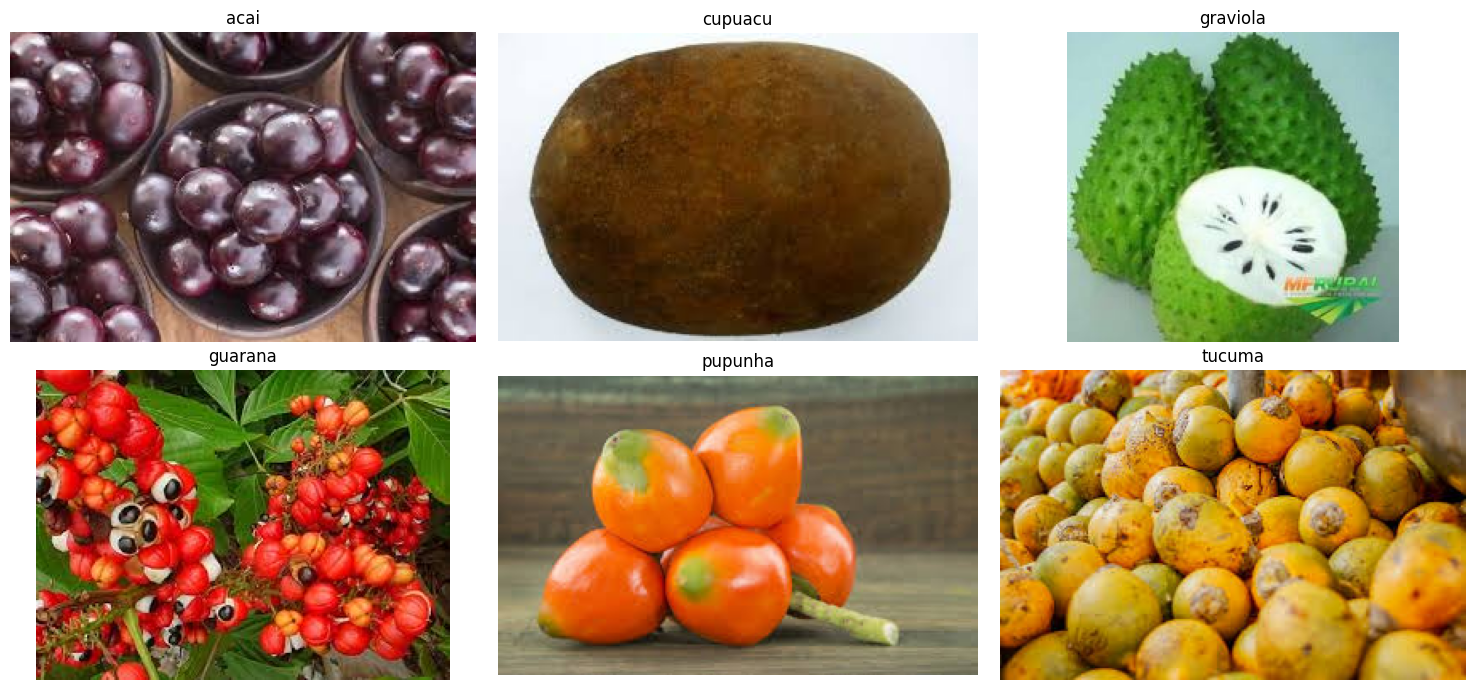

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

#load dataset
train_dir = "/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train"

# Get the list of class directories
classes = sorted(os.listdir(train_dir))
num_classes = len(classes)

# Setup the figure for a grid with two rows
cols = (num_classes + 1) // 2
plt.figure(figsize=(15, 7))

for i, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    # Get all images in the class directory
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    # Select one image randomly
    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    # Load and display
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
corrupted_images = []
# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Attempt to open and verify the image
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError):
                # If corrupted, remove and log
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}") [cite: 493]

if not corrupted_images:
  print("No Corrupted Images Found.")
else:
  print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [13]:
import tensorflow as tf

img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
).map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
).map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with

In [14]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Fully Connected Network
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#Task 4: Compile the Model

In [15]:
# Task 4: Compilation and Training
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_fruit_model.h5', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.1644 - loss: 2.2879

3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.1806 - loss: 2.5029 - val_accuracy: 0.0000e+00 - val_loss: 2.2121
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.1887 - loss: 1.8620

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 732ms/step - accuracy: 0.2222 - loss: 1.8091 - val_accuracy: 0.7778 - val_loss: 1.6018
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 0.4167 - loss: 1.5884 - val_accuracy: 0.5556 - val_loss: 1.6302
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.3738 - loss: 1.4309

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 627ms/step - accuracy: 0.4028 - loss: 1.4087 - val_accuracy: 0.7222 - val_loss: 1.3067
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.5885 - loss: 1.2219

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 645ms/step - accuracy: 0.6250 - loss: 1.1983 - val_accuracy: 0.7778 - val_loss: 1.1076
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6759 - loss: 1.0282

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 576ms/step - accuracy: 0.9861 - loss: 0.0481 - val_accuracy: 0.9444 - val_loss: 0.2127
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 578ms/step - accuracy: 1.0000 - loss: 0.0194 - val_accuracy: 0.8333 - val_loss: 0.3030
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 514ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 0.8333 - val_loss: 0.3969
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.8333 - val_loss: 0.3743
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 526ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.8333 - val_loss: 0.3085
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 854ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.8333 - val_loss: 0.2411
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 1.0000 - loss: 0.0022

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 793ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.8333 - val_loss: 0.2045
Epoch 22/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 1.0000 - loss: 0.0018

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 590ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.1972
Epoch 23/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 1.0000 - loss: 0.0016

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 584ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8889 - val_loss: 0.1937
Epoch 24/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 1.0000 - loss: 0.0013

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 578ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8889 - val_loss: 0.1912
Epoch 25/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 572ms/step - accuracy: 1.0000 - loss: 9.2182e-04 - val_accuracy: 0.8333 - val_loss: 0.1949
Epoch 26/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 1.0000 - loss: 7.4622e-04 - val_accuracy: 0.8333 - val_loss: 0.2070
Epoch 27/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 488ms/step - accuracy: 1.0000 - loss: 6.3840e-04 - val_accuracy: 0.8333 - val_loss: 0.2242
Epoch 28/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 495ms/step - accuracy: 1.0000 - loss: 5.6463e-04 - val_accuracy: 0.8333 - val_loss: 0.2415
Epoch 29/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 1.0000 - loss: 5.1248e-04 - val_accuracy: 0.8333 - val_loss: 0.2567
Epoch 30/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 557ms/step - accuracy: 1.0000 - loss: 4.7864e-04 - val_accuracy: 0.8333 - val_loss: 0.2655
Epoch 31/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 491ms/step - accuracy: 1.0000 - loss: 4.5244e-04 - v

#Task 5 -Evaluate the model


In [16]:
# Task 5: Evaluation
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.8889 - loss: 0.1912
Validation Accuracy: 0.8889


#Task 6: Save and Load the Model

In [17]:
import numpy as np
from sklearn.metrics import classification_report

# Task 6: Save and Load
model.save('final_model.h5')
new_model = tf.keras.models.load_model('final_model.h5')

# Task 7: Predictions and Report

In [18]:
# Task 7: Predictions and Report
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = new_model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
              precision    recall  f1-score   support

           2       0.00      0.00      0.00         0
           4       1.00      0.67      0.80         3
           5       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.64      0.53      0.58        18
weighted avg       0.94      0.89      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
